In [1]:
from preamble_jax import *
from scipy.optimize import curve_fit

Available devices: [CpuDevice(id=0), CpuDevice(id=1), CpuDevice(id=2), CpuDevice(id=3), CpuDevice(id=4), CpuDevice(id=5), CpuDevice(id=6), CpuDevice(id=7), CpuDevice(id=8), CpuDevice(id=9), CpuDevice(id=10), CpuDevice(id=11)]
CPU devices: [CpuDevice(id=0), CpuDevice(id=1), CpuDevice(id=2), CpuDevice(id=3), CpuDevice(id=4), CpuDevice(id=5), CpuDevice(id=6), CpuDevice(id=7), CpuDevice(id=8), CpuDevice(id=9), CpuDevice(id=10), CpuDevice(id=11)]


2025-12-03 14:01:56,756 - WARNING - File .dacerc not found. You are requesting data in public mode. To change this behaviour, create a .dacerc file in your home directory and fill it with your API key. More infos on https://dace.unige.ch


In [2]:
_params_config={
    # Ramp Model Parameters
    "r1": (17.0,18.5),
    "r2": (-8.0,-6.5),
    "r3": (-0.0001,0.0001),
    #Breathing params
    "b1":(-0.01,0.01),
    "b2":(-0.01,0.01),
    "b3":(-0.01,0.01),
    "b4":(-0.01,0.01),
    # Planetary Parameters
    "a_rstar": (18.0,18.5),
    "ecc": (0.0,0.2),
    "t0": (-0.001,0.001),
    # Stellar Parameters
    "f_cool_unocculted":(0.2,0.4),
    "spec_scale_factor": (0.95, 1.05),
    "T_unocculted": (2900,3100),
    "T_occulted": (3300,3450),    
    "T_phot": (3800,4100),
    "log_fixedspot_radii":(-1.8,-1.5), #This is the size scale of spots at the active latitudes
    # This spot is occulted
    "spot1_lon": (0.85,0.89),
    "spot1_lat": (1.79,1.83),
    "spot1_rad": (0.05,0.07),
    "spot2_lon":(-0.3,0.5),
    "spot2_lat":(1.4,1.51),
    "spot2_rad":(0.3,0.32),
    #This spot controls the overall rotational modulation
    "spot3_lon": (-1.1,-0.8),
    "spot3_lat": (0.9,1.6),
    "spot3_rad": (0.15,0.25),
}

_priors={
    # Ramp Model Parameters
    "r1": (5.0, 30.0),
    "r2": (-20, -1.0),
    "r3": (-0.01, 0.01),
    #Breathing params
    "b1": (-0.5, 0.5),
    "b2": (-0.5, 0.5),
    "b3": (-0.5, 0.5),
    "b4": (-0.5, 0.5),
    # Transit Parameters
    "a_rstar": (17.0, 21.0),
    "ecc": (0.0,0.2),
    "t0": (-0.001,0.001),
    # Stellar Parameters
    "f_cool_unocculted": (0.1,0.6),
    "spec_scale_factor": (0.5, 1.5),
    "T_unocculted": (2850,3150),
    "T_occulted": (3300,3500),    
    "T_phot": (3800,4150),
    "log_fixedspot_radii": (-3,-1),
    "spot1_lon": (0.8, 0.92),
    "spot1_lat": (1.7, 1.85),
    "spot1_rad": (0.0, 0.15),
    "spot2_lon": (0.0,1.4),
    "spot2_lat": (1.2,1.6),
    "spot2_rad": (0.0,0.5),
    "spot3_lon": (-1.4, 0.0),
    "spot3_lat": (0.8, 1.8),
    "spot3_rad": (0.0, 0.6),
}

In [3]:
def bin_testing(visit='F21',bin_edges = None,
                print_results='True',plot='True'):

    predicted_T0 = visits[f'{visit}']['T0 (BJD_TDB)'].value
    binwidth = visits[f'{visit}']['native resolution']
    exptime = visits[f'{visit}']['exp (s)']
    grism = visits[f'{visit}']['Grism']
    
    rainbow = read_rainbow(f"../../data/rainbows/{visit}_scan-combined_trimmed_pacman_spec.rainbow.npy")
    # print(f'N_wavelengths in visit {visit} = {rainbow.nwave}')
    # print(f'N_times in visit {visit} = {rainbow.ntime}')

    for i in range(len(rainbow.wavelength.value)):
        'ADD CORRECTION TO UNCERTAINTIES'
        rainbow.uncertainty[i,:] = rainbow.uncertainty[i,:] #* SED_err_factor[i]
    data_wavelengths = rainbow.wavelength.value
    img_date = rainbow.time.value
    _data_flux = rainbow.flux.value
    time_from_T0 = img_date - predicted_T0

    mean_data_flux = np.nanmean(_data_flux, axis=1)
    data_flux = _data_flux / mean_data_flux[:, np.newaxis]
    relative_err = rainbow.uncertainty.value/_data_flux

    # Label the orbits
    orbit = np.zeros_like(img_date)
    for j in range(len(img_date)):
        if j >= 1:
            if (img_date[j] - img_date[j - 1]) > 0.01:
                orbit[j] = (orbit[j - 1] + 1)
            else:
                orbit[j] = orbit[j - 1]
    
    # Trim the first point from each orbit
    ref_time = []
    for o in np.unique(orbit):
        first_index = np.where(orbit == o)[0][0]
        ref_time.append(img_date[first_index])
        data_flux[:, first_index] = np.nan  # Set the first point of each subsequent orbit to np.nan
        relative_err[:, first_index] = np.nan
        img_date[first_index] = np.nan
        time_from_T0[first_index] = np.nan
    
    # Set data to nan if it was in the pre-defined list of orbits to exclude
    for orbit_to_exclude in np.array([0,3,4,5]):
        data_flux[:, orbit == orbit_to_exclude] = np.nan
        relative_err[:, orbit == orbit_to_exclude] = np.nan
        img_date[orbit == orbit_to_exclude] = np.nan
        time_from_T0[orbit == orbit_to_exclude] = np.nan
    
    # Populate ramp_phase time arrays
    phase_list=[]
    for o in [0,1,2,3,4,5,6,7]:
        rphase = (img_date[orbit==o] - ref_time[o]) / 0.066
        phase_list.append(rphase)
    ramp_phase = np.concatenate(phase_list)
    
    nanmask = ~np.isnan(img_date)
    data_flux = data_flux[:,nanmask]
    relative_err = relative_err[:,nanmask]
    time_from_T0 = time_from_T0[nanmask]  
    img_date = img_date[nanmask]          
    ramp_phase = ramp_phase[nanmask]
    
    def linear_model(x, m, b):
    
        ramp = ramp_model(phase=ramp_phase,r1=10.0,r2=-6,r3=0.0)
    
        return (m * x + b)*ramp
    
    # Residual function (for minimization)
    def residual(params, x, y):
        m, b = params
        model = linear_model(x, m, b)
        return y - model # Residual = data - model
        
    'PLOT EACH LIGHT CURVE WITH THE MODEL, NEXT TO THE RESIDUALS'
    # fig, axes = plt.subplots(1,2,figsize=(10, 1.5))
    popt_list = []
    initial_guess = [-0.03, 1.0]  # m, b
    for i in range(len(data_wavelengths)):
        # for ax in axes:
        #     ax.clear()
        
        time = time_from_T0
        flux = data_flux[i, :]
        err = relative_err[i, :]
    
        # Fit using curve_fit
        popt, pcov = curve_fit(
            lambda x, m, b: linear_model(x, m, b),
            time,
            flux,
            sigma = err,
            p0=initial_guess,
            maxfev = 100000
        )
        # Best-fit parameters
        popt_list.append(popt)
        m_opt, b_opt = popt
        # print("Best-fit params:", popt)
        model_flux = linear_model(time_from_T0, m_opt, b_opt)
        residual = data_flux[i,:]-model_flux
        rms = int(np.nanstd(residual)*1e6)
        chisq = np.nansum((residual/relative_err[i,:])**2)
        rchisq = chisq/(np.sum(~np.isnan(time_from_T0))-2)
            
        if print_results:
            if i == 0:
                print('Wavelength Median_rel_err linear_rms r_chisq')
            print(f'{data_wavelengths[i]:.5f} {int(np.nanmedian(relative_err[i,:])*1e6)} {rms} {rchisq:.3f}')
        # axes[0].set_title(f'{data_wavelengths[i]:.5f} micron')
        # axes[1].set_title(f'Residual RMS = {rms} ppm')
        # axes[0].errorbar(img_date, data_flux[i,:],yerr=relative_err[i,:],fmt='o',
        #                  ms=1, label = f'Reduced chi-squared = {rchisq:.3f}',color='b')
        # axes[0].legend(loc = 'upper right')
        # axes[0].plot(img_date, model_flux,color='r')
        # axes[1].scatter(img_date, data_flux[i,:]-model_flux,s=1)
        # plt.savefig(f'../figs/{visit}_unbinned_lc_{i}.png')
    
    'RMS and Bin Edge Plots'
    if plot:
        fig, axes = plt.subplots(4,1,figsize=(8.0, 8.5),sharex=True)
        axes[2].set_title(f'{visit} Nbins = {len(bin_edges)-1}')
        axes[0].set_title(f'Data - Model (slope x ramp)')
        axes[3].set_xlabel(r'Wavelength $\mu$m')
        axes[0].set_ylabel(f'RMS (ppm)')
        axes[1].set_ylabel(r'Reduced $\chi^2$')
        axes[2].set_ylabel(f'RMS (ppm)')
        axes[3].set_ylabel(r'Reduced $\chi^2$')
    rms_list = []
    for i in range(len(data_wavelengths)):
        m_opt, b_opt = popt_list[i]
        model_flux = linear_model(time_from_T0, m_opt, b_opt)
        residual = data_flux[i,:]-model_flux
        rms = int(np.nanstd(residual)*1e6)
        rms_list.append(rms )
        chisq = np.nansum((residual/relative_err[i,:])**2)
        rchisq = chisq/(np.sum(~np.isnan(time_from_T0))-2)
        if plot:
            axes[0].scatter(data_wavelengths[i], rms,color='pink',zorder=100)
            axes[1].scatter(data_wavelengths[i], rchisq, color='k',zorder=100)

    if plot:
        for edge in bin_edges.value:
            axes[0].axvline(edge,color='r',alpha = 0.5)
            axes[1].axvline(edge,color='r',alpha = 0.5)
            axes[2].axvline(edge,color='r',alpha = 0.5)
            axes[3].axvline(edge,color='r',alpha = 0.5)
        axes[0].plot(data_wavelengths, rms_list,color='k')

    # Now do this again but with a binnned light curve

    predicted_T0 = visits[f'{visit}']['T0 (BJD_TDB)'].value
    binwidth = visits[f'{visit}']['native resolution']
    exptime = visits[f'{visit}']['exp (s)']
    grism = visits[f'{visit}']['Grism']
    
    rainbow = read_rainbow(f"../../data/rainbows/{visit}_scan-combined_trimmed_pacman_spec.rainbow.npy")
    for i in range(len(rainbow.wavelength.value)):
        'ADD CORRECTION TO UNCERTAINTIES'
        rainbow.uncertainty[i,:] = rainbow.uncertainty[i,:] #* SED_err_factor[i]
    rainbow = rainbow.bin(wavelength_edges=bin_edges)
    
    data_wavelengths = rainbow.wavelength.value
    img_date = rainbow.time.value
    _data_flux = rainbow.flux.value
    relative_err = rainbow.uncertainty.value/_data_flux
    time_from_T0 = img_date - predicted_T0

    mean_data_flux = np.nanmean(_data_flux, axis=1)
    data_flux = _data_flux / mean_data_flux[:, np.newaxis]
    
    # Label the orbits
    orbit = np.zeros_like(img_date)
    for j in range(len(img_date)):
        if j >= 1:
            if (img_date[j] - img_date[j - 1]) > 0.01:
                orbit[j] = (orbit[j - 1] + 1)
            else:
                orbit[j] = orbit[j - 1]
    
    # Trim the first point from each orbit
    ref_time = []
    for o in np.unique(orbit):
        first_index = np.where(orbit == o)[0][0]
        ref_time.append(img_date[first_index])
        data_flux[:, first_index] = np.nan  # Set the first point of each subsequent orbit to np.nan
        relative_err[:, first_index] = np.nan
        img_date[first_index] = np.nan
        time_from_T0[first_index] = np.nan
    
    # Set data to nan if it was in the pre-defined list of orbits to exclude
    for orbit_to_exclude in np.array([0,3,4,5]):
        data_flux[:, orbit == orbit_to_exclude] = np.nan
        relative_err[:, orbit == orbit_to_exclude] = np.nan
        img_date[orbit == orbit_to_exclude] = np.nan
        time_from_T0[orbit == orbit_to_exclude] = np.nan
    
    # Populate ramp_phase time arrays
    phase_list=[]
    for o in [0,1,2,3,4,5,6,7]:
        rphase = (img_date[orbit==o] - ref_time[o]) / 0.066
        phase_list.append(rphase)
    ramp_phase = np.concatenate(phase_list)
    
    nanmask = ~np.isnan(img_date)
    data_flux = data_flux[:,nanmask]
    relative_err = relative_err[:,nanmask]
    time_from_T0 = time_from_T0[nanmask]  
    img_date = img_date[nanmask]          
    ramp_phase = ramp_phase[nanmask]
        
    'PLOT EACH LIGHT CURVE WITH THE MODEL, NEXT TO THE RESIDUALS'
    # lc_fig, lc_axes = plt.subplots(1,2,figsize=(10, 1.5))
    popt_list = []
    for i in range(len(data_wavelengths)):
        # for ax in axes:
        #     ax.clear()
        
        time = time_from_T0
        flux = data_flux[i, :]
        err = relative_err[i, :]
    
        # Fit using curve_fit
        popt, pcov = curve_fit(
            lambda x, m, b: linear_model(x, m, b),
            time,
            flux,
            sigma = err,
            p0=initial_guess,
            maxfev = 100000
        )
        # Best-fit parameters
        popt_list.append(popt)
        m_opt, b_opt = popt
        model_flux = linear_model(time_from_T0, m_opt, b_opt)
        residual = data_flux[i,:]-model_flux
        rms = int(np.nanstd(residual)*1e6)
        chisq = np.nansum((residual/relative_err[i,:])**2)
        rchisq = chisq/(np.sum(~np.isnan(time_from_T0))-2)
        if print_results:
            if i == 0:
                print('BINNED: Wavelength Median_rel_err linear_rms r_chisq')
            print(f'{data_wavelengths[i]:.5f} {int(np.nanmedian(relative_err[i,:])*1e6)} {rms} {rchisq:.3f}')
        # lc_axes[0].set_title(f'{data_wavelengths[i]:.5f} micron')
        # lc_axes[1].set_title(f'Residual RMS = {rms} ppm')
        # lc_axes[0].errorbar(img_date, data_flux[i,:],yerr=relative_err[i,:],fmt='o',
        #                  ms=1, label = f'Reduced chi-squared = {rchisq:.3f}',color='b')
        # lc_axes[0].legend(loc = 'upper right')
        # lc_axes[0].plot(img_date, model_flux,color='r')
        # lc_axes[1].scatter(img_date, data_flux[i,:]-model_flux,s=1)
        # plt.savefig(f'../figs/{visit}_binned_lc_{i}.png')
    
    'PLOT THE RMS'
    rms_list = []
    for i in range(len(data_wavelengths)):
        m_opt, b_opt = popt_list[i]
        model_flux = linear_model(time_from_T0, m_opt, b_opt)
        residual = data_flux[i,:]-model_flux
        rms = int(np.nanstd(residual)*1e6)
        rms_list.append( rms )
        chisq = np.nansum((residual/relative_err[i,:])**2)
        rchisq = chisq/(np.sum(~np.isnan(time_from_T0))-2)
        if plot:
            axes[2].scatter(data_wavelengths[i], rms,color='pink',zorder=100)
            axes[3].scatter(data_wavelengths[i], rchisq,color='k',zorder=100)
            

    if plot:
        axes[2].plot(data_wavelengths, rms_list,color='k')
        plt.savefig(f'../../figs/{visit}_{len(bin_edges)-1}bins_rms_plots.png',dpi=300)
        plt.show()

    return rms_list

  0%|          | 0/45 [00:00<?, ?it/s]

🌈🤖 It looks like you're trying to bin in wavelength for a
`Rainbow` object that might not be normalized. In the
current version of `chromatic`, binning before normalizing
might give inaccurate results if the typical uncertainty
varies strongly with wavelength.

Please consider normalizing first, for example with
`rainbow.normalize().bin(...)`
so that all uncertainties will effectively be relative,
and the inverse variance weighting used for binning
wavelengths together will give more reasonable answers.

If you really need to bin before normalizing, please submit
an Issue at github.com/zkbt/chromatic/, and we'll try to
prioritize implementing a statistically sound solution as
soon as possible!



  0%|          | 0/162 [00:00<?, ?it/s]

🌈🤖 It looks like you're trying to bin in wavelength for a
`Rainbow` object that might not be normalized. In the
current version of `chromatic`, binning before normalizing
might give inaccurate results if the typical uncertainty
varies strongly with wavelength.

Please consider normalizing first, for example with
`rainbow.normalize().bin(...)`
so that all uncertainties will effectively be relative,
and the inverse variance weighting used for binning
wavelengths together will give more reasonable answers.

If you really need to bin before normalizing, please submit
an Issue at github.com/zkbt/chromatic/, and we'll try to
prioritize implementing a statistically sound solution as
soon as possible!



  0%|          | 0/162 [00:00<?, ?it/s]

...

  0%|          | 0/162 [00:00<?, ?it/s]

🌈🤖 It looks like you're trying to bin in wavelength for a
`Rainbow` object that might not be normalized. In the
current version of `chromatic`, binning before normalizing
might give inaccurate results if the typical uncertainty
varies strongly with wavelength.

Please consider normalizing first, for example with
`rainbow.normalize().bin(...)`
so that all uncertainties will effectively be relative,
and the inverse variance weighting used for binning
wavelengths together will give more reasonable answers.

If you really need to bin before normalizing, please submit
an Issue at github.com/zkbt/chromatic/, and we'll try to
prioritize implementing a statistically sound solution as
soon as possible!



  0%|          | 0/162 [00:00<?, ?it/s]

🌈🤖 It looks like you're trying to bin in wavelength for a
`Rainbow` object that might not be normalized. In the
current version of `chromatic`, binning before normalizing
might give inaccurate results if the typical uncertainty
varies strongly with wavelength.

Please consider normalizing first, for example with
`rainbow.normalize().bin(...)`
so that all uncertainties will effectively be relative,
and the inverse variance weighting used for binning
wavelengths together will give more reasonable answers.

If you really need to bin before normalizing, please submit
an Issue at github.com/zkbt/chromatic/, and we'll try to
prioritize implementing a statistically sound solution as
soon as possible!



  0%|          | 0/162 [00:00<?, ?it/s]

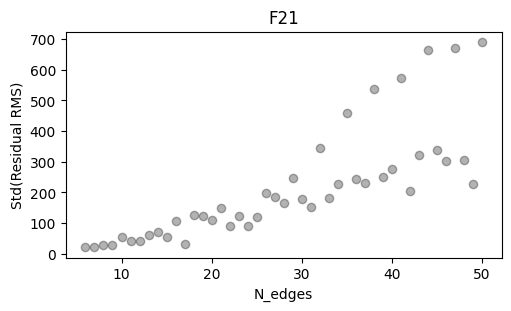

  0%|          | 0/45 [00:00<?, ?it/s]

🌈🤖 It looks like you're trying to bin in wavelength for a
`Rainbow` object that might not be normalized. In the
current version of `chromatic`, binning before normalizing
might give inaccurate results if the typical uncertainty
varies strongly with wavelength.

Please consider normalizing first, for example with
`rainbow.normalize().bin(...)`
so that all uncertainties will effectively be relative,
and the inverse variance weighting used for binning
wavelengths together will give more reasonable answers.

If you really need to bin before normalizing, please submit
an Issue at github.com/zkbt/chromatic/, and we'll try to
prioritize implementing a statistically sound solution as
soon as possible!



  0%|          | 0/160 [00:00<?, ?it/s]

🌈🤖 It looks like you're trying to bin in wavelength for a
`Rainbow` object that might not be normalized. In the
current version of `chromatic`, binning before normalizing
might give inaccurate results if the typical uncertainty
varies strongly with wavelength.

Please consider normalizing first, for example with
`rainbow.normalize().bin(...)`
so that all uncertainties will effectively be relative,
and the inverse variance weighting used for binning
wavelengths together will give more reasonable answers.

If you really need to bin before normalizing, please submit
an Issue at github.com/zkbt/chromatic/, and we'll try to
prioritize implementing a statistically sound solution as
soon as possible!



  0%|          | 0/160 [00:00<?, ?it/s]

...

🌈🤖 It looks like you're trying to bin in wavelength for a
`Rainbow` object that might not be normalized. In the
current version of `chromatic`, binning before normalizing
might give inaccurate results if the typical uncertainty
varies strongly with wavelength.

Please consider normalizing first, for example with
`rainbow.normalize().bin(...)`
so that all uncertainties will effectively be relative,
and the inverse variance weighting used for binning
wavelengths together will give more reasonable answers.

If you really need to bin before normalizing, please submit
an Issue at github.com/zkbt/chromatic/, and we'll try to
prioritize implementing a statistically sound solution as
soon as possible!



  0%|          | 0/160 [00:00<?, ?it/s]

🌈🤖 It looks like you're trying to bin in wavelength for a
`Rainbow` object that might not be normalized. In the
current version of `chromatic`, binning before normalizing
might give inaccurate results if the typical uncertainty
varies strongly with wavelength.

Please consider normalizing first, for example with
`rainbow.normalize().bin(...)`
so that all uncertainties will effectively be relative,
and the inverse variance weighting used for binning
wavelengths together will give more reasonable answers.

If you really need to bin before normalizing, please submit
an Issue at github.com/zkbt/chromatic/, and we'll try to
prioritize implementing a statistically sound solution as
soon as possible!



  0%|          | 0/160 [00:00<?, ?it/s]

<Figure size 640x480 with 0 Axes>

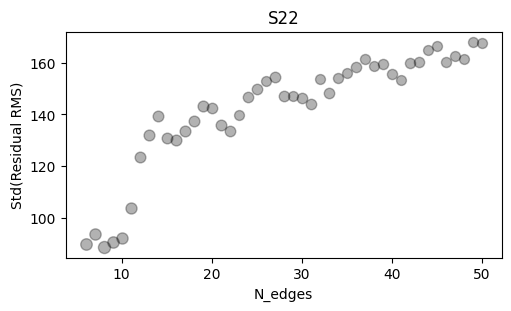

<Figure size 640x480 with 0 Axes>

In [4]:
visit = 'F21'
fig, ax = plt.subplots(1,1,figsize=(5,3))
for N_edges in tqdm(list(range(6, 51))):

    n_edges = int(N_edges)
    new_bin_edges = np.linspace(1.14,1.64,n_edges) * u.micron
    _rms = bin_testing(visit='F21',bin_edges = new_bin_edges,
            print_results = False,plot=False)
    rms = np.nanstd(_rms)
    mean_rms = np.nanmean(_rms)
    max_rms = np.nanmax(_rms)/rms
    rms_stat = np.nanmin(_rms)/np.nanmean(_rms)

    ax.scatter(n_edges, rms, color='k',alpha=0.3)

ax.set_xlabel('N_edges')
ax.set_ylabel('Std(Residual RMS)')
ax.set_title('F21')
plt.savefig(f'../../figs/{visit}_rmsvsbinsize.png',dpi=200)
plt.show()
plt.clf()

visit = 'S22'
fig, ax = plt.subplots(1,1,figsize=(5,3))
for N_edges in tqdm(list(range(6, 51))):

    n_edges = int(N_edges)
    new_bin_edges = np.linspace(0.82,1.13,n_edges) * u.micron
    _rms = bin_testing(visit='S22',bin_edges = new_bin_edges,
            print_results = False,plot=False)
    rms = np.nanstd(_rms)
    mean_rms = np.nanmean(_rms)
    max_rms = np.nanmax(_rms)/rms
    rms_stat = np.nanmin(_rms)/np.nanmean(_rms)

    ax.scatter(n_edges, rms,s=float((rms_stat*10)**2),color='k',alpha=0.3)

ax.set_xlabel('N_edges')
ax.set_ylabel('Std(Residual RMS)')
ax.set_title('S22')
plt.savefig(f'../../figs/{visit}_rmsvsbinsize.png',dpi=200)
plt.show()
plt.clf()

1.140000
1.152500
1.165000
1.177500
1.190000
1.202500
1.215000
1.227500
1.240000
1.252500
1.265000
1.277500
1.290000
1.302500
1.315000
1.327500
1.340000
1.352500
1.365000
1.377500
1.390000
1.402500
1.415000
1.427500
1.440000
1.452500
1.465000
1.477500
1.490000
1.502500
1.515000
1.527500
1.540000
1.552500
1.565000
1.577500
1.590000
1.602500
1.615000
1.627500
1.640000
Wavelength Median_rel_err linear_rms r_chisq
1.14296 353 1685 23.273
1.14759 349 640 3.455
1.15222 346 1380 16.288
1.15685 346 1951 32.491
1.16149 346 3271 91.260
1.16612 342 967 8.152
1.17075 339 1684 25.320
1.17539 336 1534 21.352
1.18002 334 1433 18.761
1.18465 332 623 3.598
1.18929 330 821 6.306
1.19392 329 2621 65.128
1.19855 328 1185 13.287
1.20318 326 623 3.745
1.20782 323 579 3.293
1.21245 321 628 3.916
1.21708 320 2313 53.587
1.22172 318 2097 44.342
1.22635 316 675 4.659
1.23098 315 1239 15.828
1.23561 314 1520 23.849
1.24025 313 881 8.058
1.24488 313 1434 21.421
1.24951 313 1091 12.410
1.25415 312 500 2.626
1.2587

🌈🤖 It looks like you're trying to bin in wavelength for a
`Rainbow` object that might not be normalized. In the
current version of `chromatic`, binning before normalizing
might give inaccurate results if the typical uncertainty
varies strongly with wavelength.

Please consider normalizing first, for example with
`rainbow.normalize().bin(...)`
so that all uncertainties will effectively be relative,
and the inverse variance weighting used for binning
wavelengths together will give more reasonable answers.

If you really need to bin before normalizing, please submit
an Issue at github.com/zkbt/chromatic/, and we'll try to
prioritize implementing a statistically sound solution as
soon as possible!



  0%|          | 0/162 [00:00<?, ?it/s]

BINNED: Wavelength Median_rel_err linear_rms r_chisq
1.14625 218 594 7.557
1.15875 210 621 8.913
1.17125 206 995 23.882
1.18375 202 683 11.625
1.19625 200 713 13.047
1.20875 196 576 8.813
1.22125 193 512 7.163
1.23375 191 535 7.980
1.24625 190 507 7.233
1.25875 189 570 9.262
1.27125 189 565 9.167
1.28375 187 722 15.078
1.29625 185 3477 359.711
1.30875 185 2925 254.901
1.32125 183 837 21.364
1.33375 182 872 23.343
1.34625 182 965 28.665
1.35875 183 1203 44.168
1.37125 184 750 16.956
1.38375 186 574 9.731
1.39625 186 550 8.932
1.40875 184 475 6.811
1.42125 184 633 12.151
1.43375 183 905 24.762
1.44625 183 841 21.500
1.45875 184 825 20.445
1.47125 186 795 18.798
1.48375 186 997 29.328
1.49625 186 867 22.333
1.50875 185 567 9.578
1.52125 183 705 15.091
1.53375 184 591 10.603
1.54625 184 615 11.361
1.55875 185 540 8.709
1.57125 186 626 11.604
1.58375 187 718 15.136
1.59625 186 553 9.090
1.60875 186 1215 43.154
1.62125 189 825 19.476
1.63375 189 728 15.122


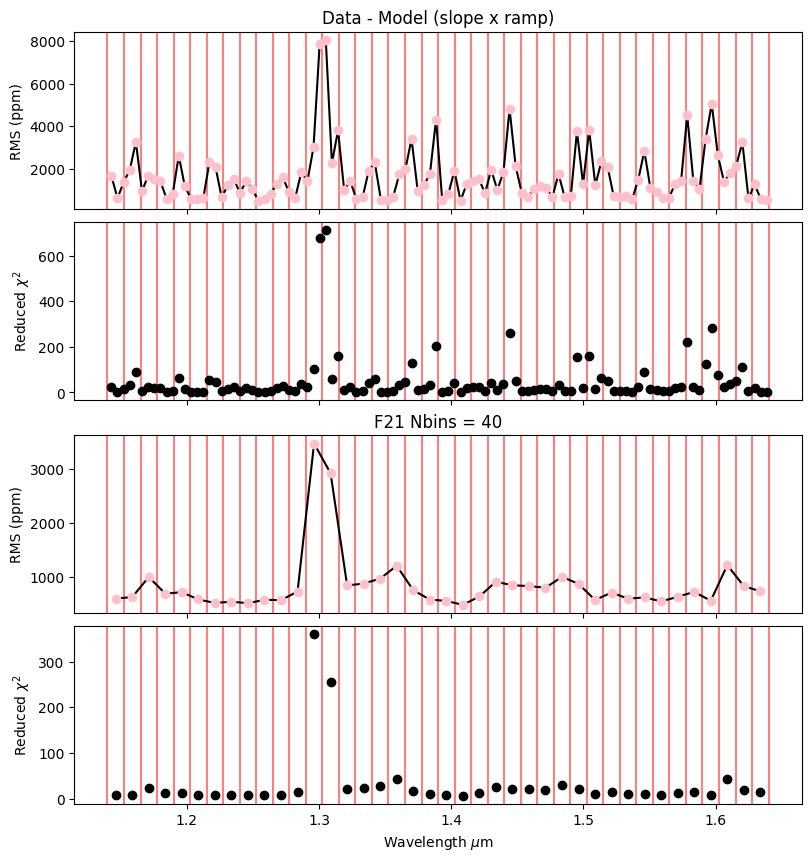

In [13]:
'FOR THE TRANSMISSION LIGHT CURVES'
F21_bin_edges = np.linspace(1.14,1.64,41) * u.micron

for edge in F21_bin_edges:
    print(f'{edge.value:.6f}')
    
rms = bin_testing(visit='F21',
            bin_edges = F21_bin_edges,
            print_results = True,plot=True)

1.140000
1.156667
1.173333
1.190000
1.206667
1.223333
1.240000
1.256667
1.273333
1.290000
1.306667
1.323333
1.340000
1.356667
1.373333
1.390000
1.406667
1.423333
1.440000
1.456667
1.473333
1.490000
1.506667
1.523333
1.540000
1.556667
1.573333
1.590000
1.606667
1.623333
1.640000
Wavelength Median_rel_err linear_rms r_chisq
1.14296 353 1685 23.273
1.14759 349 640 3.455
1.15222 346 1380 16.288
1.15685 346 1951 32.491
1.16149 346 3271 91.260
1.16612 342 967 8.152
1.17075 339 1684 25.320
1.17539 336 1534 21.352
1.18002 334 1433 18.761
1.18465 332 623 3.598
1.18929 330 821 6.306
1.19392 329 2621 65.128
1.19855 328 1185 13.287
1.20318 326 623 3.745
1.20782 323 579 3.293
1.21245 321 628 3.916
1.21708 320 2313 53.587
1.22172 318 2097 44.342
1.22635 316 675 4.659
1.23098 315 1239 15.828
1.23561 314 1520 23.849
1.24025 313 881 8.058
1.24488 313 1434 21.421
1.24951 313 1091 12.410
1.25415 312 500 2.626
1.25878 311 589 3.658
1.26341 311 823 7.160
1.26804 311 1314 18.230
1.27268 310 1615 27.799
1.27

🌈🤖 It looks like you're trying to bin in wavelength for a
`Rainbow` object that might not be normalized. In the
current version of `chromatic`, binning before normalizing
might give inaccurate results if the typical uncertainty
varies strongly with wavelength.

Please consider normalizing first, for example with
`rainbow.normalize().bin(...)`
so that all uncertainties will effectively be relative,
and the inverse variance weighting used for binning
wavelengths together will give more reasonable answers.

If you really need to bin before normalizing, please submit
an Issue at github.com/zkbt/chromatic/, and we'll try to
prioritize implementing a statistically sound solution as
soon as possible!



  0%|          | 0/162 [00:00<?, ?it/s]

BINNED: Wavelength Median_rel_err linear_rms r_chisq
1.14833 187 498 7.239
1.16500 180 608 11.569
1.18167 176 477 7.547
1.19833 172 659 14.927
1.21500 169 570 11.696
1.23167 166 596 13.161
1.24833 165 494 9.190
1.26500 164 517 10.198
1.28167 162 487 9.166
1.29833 160 992 39.091
1.31500 159 888 31.684
1.33167 157 859 30.234
1.34833 158 852 29.720
1.36500 159 563 12.847
1.38167 160 477 9.035
1.39833 161 645 16.428
1.41500 159 623 15.646
1.43167 159 620 15.499
1.44833 159 612 15.162
1.46500 160 527 11.075
1.48167 161 839 27.708
1.49833 161 642 16.191
1.51500 159 725 21.285
1.53167 159 552 12.337
1.54833 160 632 15.946
1.56500 160 528 11.080
1.58167 162 713 19.918
1.59833 161 721 20.505
1.61500 162 1053 42.684
1.63167 164 689 18.086


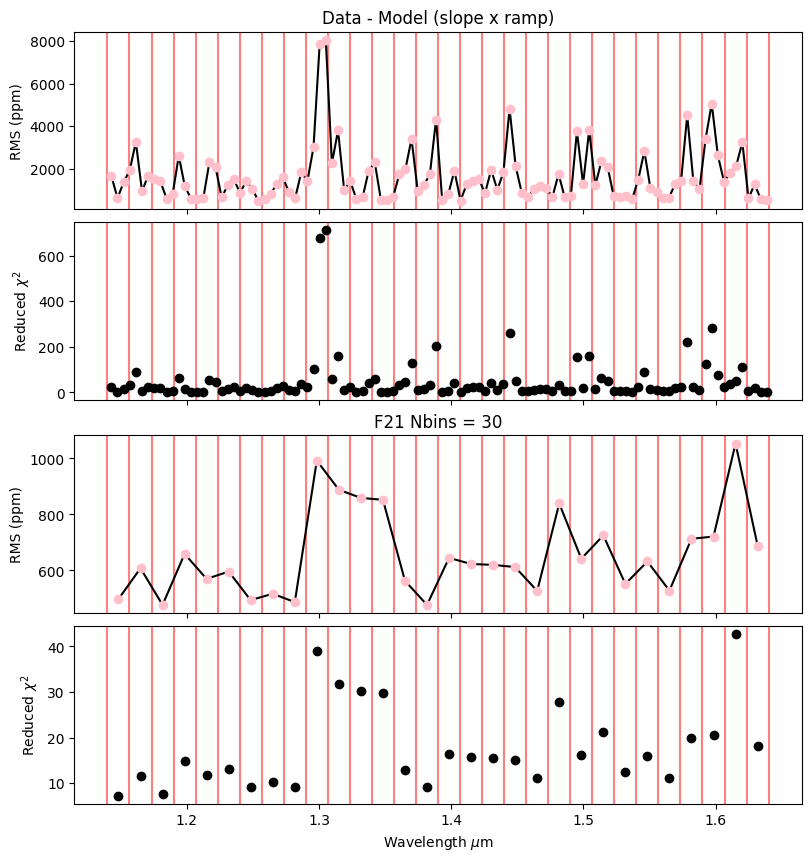

In [14]:
F21_bin_edges = np.linspace(1.14,1.64,31) * u.micron

for edge in F21_bin_edges:
    print(f'{edge.value:.6f}')
    
rms = bin_testing(visit='F21',
            bin_edges = F21_bin_edges,
            print_results = True,plot=True)

1.122105
1.15917
1.210135
1.25183
1.28426
1.325955
1.34912
1.390815
1.41398
1.460305
1.488105
1.5298
1.566865
1.62245
1.64
Wavelength Median_rel_err linear_rms r_chisq
1.14296 353 1685 23.273
1.14759 349 640 3.455
1.15222 346 1380 16.288
1.15685 346 1951 32.491
1.16149 346 3271 91.260
1.16612 342 967 8.152
1.17075 339 1684 25.320
1.17539 336 1534 21.352
1.18002 334 1433 18.761
1.18465 332 623 3.598
1.18929 330 821 6.306
1.19392 329 2621 65.128
1.19855 328 1185 13.287
1.20318 326 623 3.745
1.20782 323 579 3.293
1.21245 321 628 3.916
1.21708 320 2313 53.587
1.22172 318 2097 44.342
1.22635 316 675 4.659
1.23098 315 1239 15.828
1.23561 314 1520 23.849
1.24025 313 881 8.058
1.24488 313 1434 21.421
1.24951 313 1091 12.410
1.25415 312 500 2.626
1.25878 311 589 3.658
1.26341 311 823 7.160
1.26804 311 1314 18.230
1.27268 310 1615 27.799
1.27731 309 904 8.740
1.28194 309 643 4.434
1.28658 308 1849 36.831
1.29121 305 1432 22.465
1.29584 304 3026 101.572
1.30047 305 7847 678.096
1.30511 306 8052 7

🌈🤖 It looks like you're trying to bin in wavelength for a
`Rainbow` object that might not be normalized. In the
current version of `chromatic`, binning before normalizing
might give inaccurate results if the typical uncertainty
varies strongly with wavelength.

Please consider normalizing first, for example with
`rainbow.normalize().bin(...)`
so that all uncertainties will effectively be relative,
and the inverse variance weighting used for binning
wavelengths together will give more reasonable answers.

If you really need to bin before normalizing, please submit
an Issue at github.com/zkbt/chromatic/, and we'll try to
prioritize implementing a statistically sound solution as
soon as possible!



  0%|          | 0/162 [00:00<?, ?it/s]

BINNED: Wavelength Median_rel_err linear_rms r_chisq
1.14064 174 603 12.301
1.18465 100 478 23.124
1.23098 105 473 20.665
1.26804 117 566 23.863
1.30511 101 551 30.270
1.33754 134 449 11.546
1.36997 101 483 23.483
1.40240 136 462 11.807
1.43714 95 491 27.073
1.47420 124 518 17.678
1.50895 101 503 25.288
1.54833 107 510 23.166
1.59466 88 566 41.744
1.63122 160 680 18.568


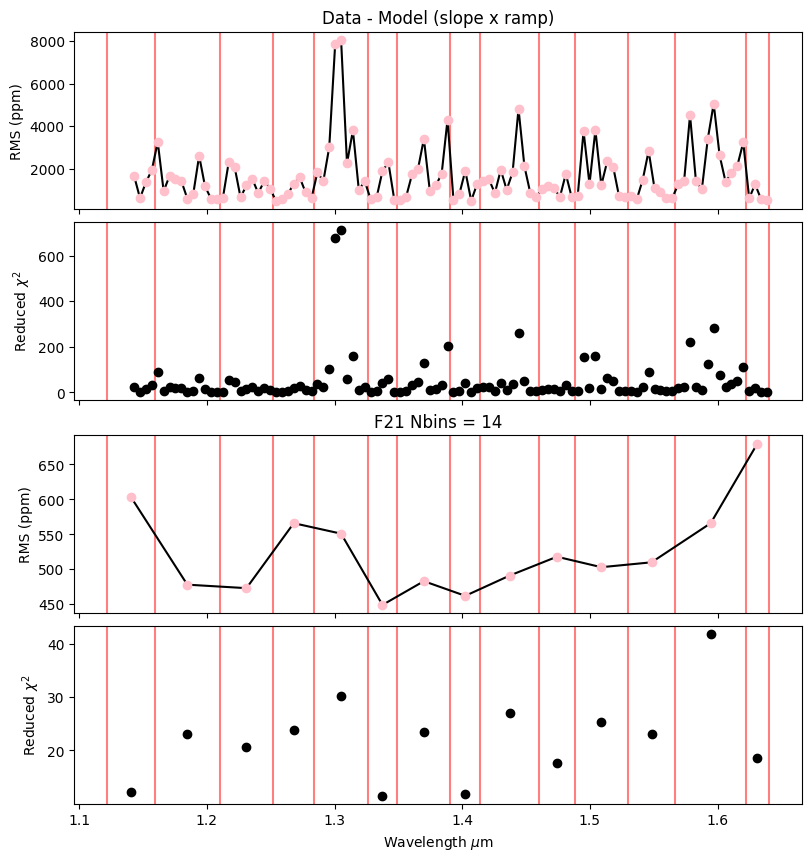

In [7]:
F21_bin_edges = np.array([1.122105, 1.159170,
                          1.210135, 1.25183, 1.28426,
                          1.325955, 1.34912, 1.390815,
                          1.413980, 
                          1.460305, 1.488105,
                          1.5298, 1.566865,
                          1.62245,1.64]) * u.micron

for edge in F21_bin_edges:
    print(edge.value)
    
rms = bin_testing(visit='F21',
            bin_edges = F21_bin_edges,
            print_results = True,plot=True)

1.14064
1.16381
1.18234
1.20087
1.21477
1.23793
1.25647
1.28426
1.31669
1.33059
1.34449
1.35839
1.39082
1.40935
1.42325
1.43715
1.45568
1.47421
1.51127
1.5298
1.54834
1.5715
1.62246
1.645
Wavelength Median_rel_err linear_rms r_chisq
1.14296 353 1685 23.273
1.14759 349 640 3.455
1.15222 346 1380 16.288
1.15685 346 1951 32.491
1.16149 346 3271 91.260
1.16612 342 967 8.152
1.17075 339 1684 25.320
1.17539 336 1534 21.352
1.18002 334 1433 18.761
1.18465 332 623 3.598
1.18929 330 821 6.306
1.19392 329 2621 65.128
1.19855 328 1185 13.287
1.20318 326 623 3.745
1.20782 323 579 3.293
1.21245 321 628 3.916
1.21708 320 2313 53.587
1.22172 318 2097 44.342
1.22635 316 675 4.659
1.23098 315 1239 15.828
1.23561 314 1520 23.849
1.24025 313 881 8.058
1.24488 313 1434 21.421
1.24951 313 1091 12.410
1.25415 312 500 2.626
1.25878 311 589 3.658
1.26341 311 823 7.160
1.26804 311 1314 18.230
1.27268 310 1615 27.799
1.27731 309 904 8.740
1.28194 309 643 4.434
1.28658 308 1849 36.831
1.29121 305 1432 22.465
1.2

🌈🤖 It looks like you're trying to bin in wavelength for a
`Rainbow` object that might not be normalized. In the
current version of `chromatic`, binning before normalizing
might give inaccurate results if the typical uncertainty
varies strongly with wavelength.

Please consider normalizing first, for example with
`rainbow.normalize().bin(...)`
so that all uncertainties will effectively be relative,
and the inverse variance weighting used for binning
wavelengths together will give more reasonable answers.

If you really need to bin before normalizing, please submit
an Issue at github.com/zkbt/chromatic/, and we'll try to
prioritize implementing a statistically sound solution as
soon as possible!



  0%|          | 0/162 [00:00<?, ?it/s]

BINNED: Wavelength Median_rel_err linear_rms r_chisq
1.15223 155 583 14.378
1.17307 169 499 8.966
1.19161 165 591 13.141
1.20782 186 565 9.376
1.22635 141 478 11.694
1.24720 156 497 10.342
1.27036 126 598 22.819
1.30048 115 550 23.314
1.32364 173 500 8.550
1.33754 173 445 6.792
1.35144 173 527 9.489
1.37460 114 497 19.244
1.40009 152 503 11.169
1.41630 174 660 14.664
1.43020 174 498 8.355
1.44642 151 506 11.530
1.46495 152 529 12.448
1.49274 108 636 35.413
1.52053 150 524 12.388
1.53907 151 547 13.383
1.55992 136 584 18.912
1.59698 92 636 48.291
1.63373 155 669 18.984


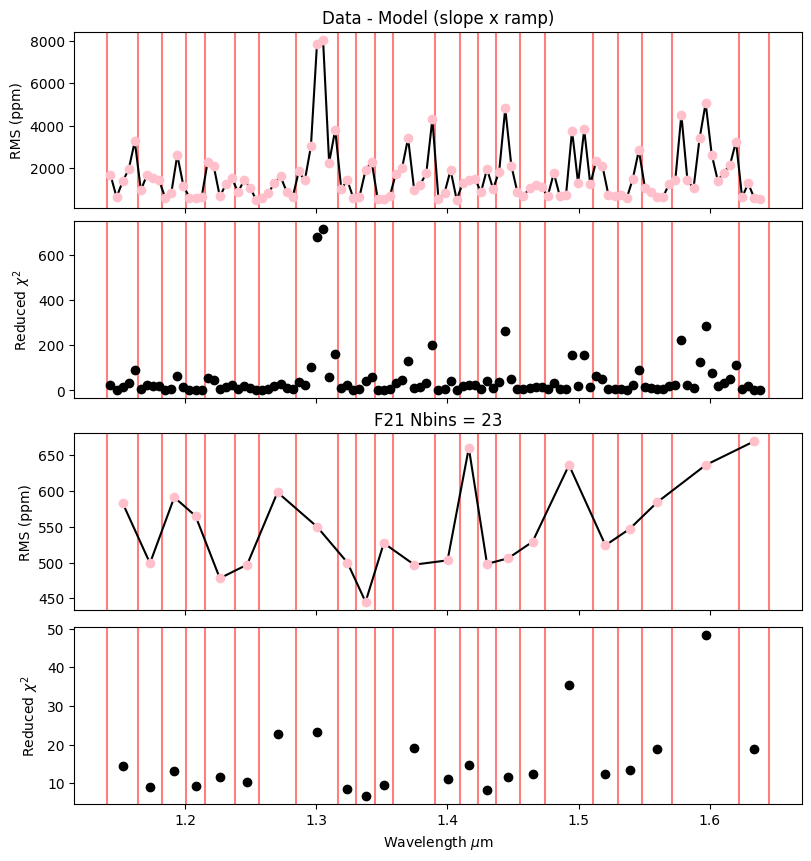

In [8]:
F21_bin_edges =jnp.array([
1.14064,
1.16381,
1.18234,
1.20087,
1.21477,
1.23793,
1.25647,
1.28426,
1.31669,
1.33059,
1.34449,
1.35839,
1.39082,
1.40935,
1.42325,
1.43715,
1.45568,
1.47421,
1.51127,
1.52980,
1.54834,
1.57150,
1.62246,
1.645])*u.micron

for edge in F21_bin_edges:
    print(edge.value)
    
rms = bin_testing(visit='F21',
            bin_edges = F21_bin_edges,
            print_results = True,plot=True)

0.820000
0.827750
0.835500
0.843250
0.851000
0.858750
0.866500
0.874250
0.882000
0.889750
0.897500
0.905250
0.913000
0.920750
0.928500
0.936250
0.944000
0.951750
0.959500
0.967250
0.975000
0.982750
0.990500
0.998250
1.006000
1.013750
1.021500
1.029250
1.037000
1.044750
1.052500
1.060250
1.068000
1.075750
1.083500
1.091250
1.099000
1.106750
1.114500
1.122250
1.130000
Wavelength Median_rel_err linear_rms r_chisq
0.82183 573 715 1.596
0.82429 554 556 1.036
0.82675 539 617 1.347
0.82921 531 768 2.156
0.83167 524 763 2.186
0.83412 519 781 2.330
0.83658 514 767 2.289
0.83904 509 1098 4.790
0.84150 500 747 2.295
0.84396 497 1035 4.465
0.84642 492 1020 4.440
0.84887 487 1356 7.986
0.85133 485 1382 8.393
0.85379 482 1506 10.057
0.85625 472 883 3.593
0.85871 473 1111 5.688
0.86117 467 810 3.096
0.86362 466 928 4.090
0.86608 465 1306 8.119
0.86854 455 969 4.658
0.87100 441 540 1.542
0.87346 430 628 2.189
0.87592 425 772 3.399
0.87838 420 583 1.985
0.88083 419 962 5.420
0.88329 412 635 2.439
0.885

🌈🤖 It looks like you're trying to bin in wavelength for a
`Rainbow` object that might not be normalized. In the
current version of `chromatic`, binning before normalizing
might give inaccurate results if the typical uncertainty
varies strongly with wavelength.

Please consider normalizing first, for example with
`rainbow.normalize().bin(...)`
so that all uncertainties will effectively be relative,
and the inverse variance weighting used for binning
wavelengths together will give more reasonable answers.

If you really need to bin before normalizing, please submit
an Issue at github.com/zkbt/chromatic/, and we'll try to
prioritize implementing a statistically sound solution as
soon as possible!



  0%|          | 0/160 [00:00<?, ?it/s]

BINNED: Wavelength Median_rel_err linear_rms r_chisq
0.82387 326 506 2.477
0.83162 295 656 5.084
0.83937 285 746 7.037
0.84712 276 1092 16.094
0.85487 269 1146 18.674
0.86262 263 827 10.202
0.87037 251 718 8.430
0.87812 237 680 8.430
0.88587 229 641 8.016
0.89362 223 647 8.611
0.90137 218 633 8.667
0.90912 213 524 6.222
0.91687 204 548 7.402
0.92462 201 646 10.597
0.93237 198 614 9.870
0.94012 196 480 6.175
0.94787 191 565 9.005
0.95562 188 627 11.453
0.96337 186 535 8.469
0.97112 184 556 9.345
0.97887 182 492 7.520
0.98662 181 460 6.627
0.99437 181 600 11.239
1.00212 179 676 14.694
1.00987 177 565 10.418
1.01762 176 507 8.549
1.02537 173 426 6.201
1.03313 173 506 8.829
1.04087 171 483 8.134
1.04862 172 495 8.539
1.05638 172 455 7.204
1.06412 171 471 7.821
1.07187 170 485 8.369
1.07962 169 741 19.630
1.08737 169 608 13.284
1.09512 169 705 17.804
1.10287 169 520 9.665
1.11062 169 461 7.595
1.11837 170 459 7.484
1.12612 171 472 7.823


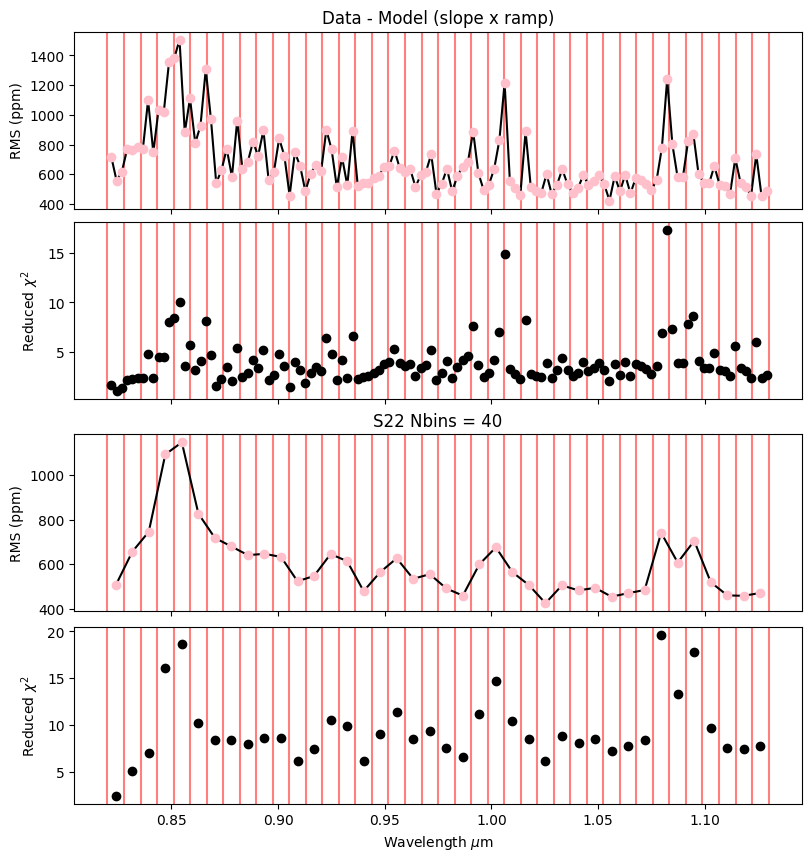

In [15]:
S22_bin_edges = np.linspace(0.82,1.13,41) * u.micron

for edge in S22_bin_edges:
    print(f'{edge.value:.6f}')
    
rms = bin_testing(visit='S22',bin_edges = S22_bin_edges,
        print_results = True,plot=True)

0.820000
0.830333
0.840667
0.851000
0.861333
0.871667
0.882000
0.892333
0.902667
0.913000
0.923333
0.933667
0.944000
0.954333
0.964667
0.975000
0.985333
0.995667
1.006000
1.016333
1.026667
1.037000
1.047333
1.057667
1.068000
1.078333
1.088667
1.099000
1.109333
1.119667
1.130000
Wavelength Median_rel_err linear_rms r_chisq
0.82183 573 715 1.596
0.82429 554 556 1.036
0.82675 539 617 1.347
0.82921 531 768 2.156
0.83167 524 763 2.186
0.83412 519 781 2.330
0.83658 514 767 2.289
0.83904 509 1098 4.790
0.84150 500 747 2.295
0.84396 497 1035 4.465
0.84642 492 1020 4.440
0.84887 487 1356 7.986
0.85133 485 1382 8.393
0.85379 482 1506 10.057
0.85625 472 883 3.593
0.85871 473 1111 5.688
0.86117 467 810 3.096
0.86362 466 928 4.090
0.86608 465 1306 8.119
0.86854 455 969 4.658
0.87100 441 540 1.542
0.87346 430 628 2.189
0.87592 425 772 3.399
0.87838 420 583 1.985
0.88083 419 962 5.420
0.88329 412 635 2.439
0.88575 407 681 2.882
0.88821 405 817 4.189
0.89067 401 726 3.365
0.89313 400 896 5.169
0.89558

🌈🤖 It looks like you're trying to bin in wavelength for a
`Rainbow` object that might not be normalized. In the
current version of `chromatic`, binning before normalizing
might give inaccurate results if the typical uncertainty
varies strongly with wavelength.

Please consider normalizing first, for example with
`rainbow.normalize().bin(...)`
so that all uncertainties will effectively be relative,
and the inverse variance weighting used for binning
wavelengths together will give more reasonable answers.

If you really need to bin before normalizing, please submit
an Issue at github.com/zkbt/chromatic/, and we'll try to
prioritize implementing a statistically sound solution as
soon as possible!



  0%|          | 0/160 [00:00<?, ?it/s]

BINNED: Wavelength Median_rel_err linear_rms r_chisq
0.82517 276 507 3.474
0.83550 251 720 8.434
0.84583 240 977 17.047
0.85617 232 1024 20.087
0.86650 224 811 13.552
0.87683 207 633 9.642
0.88717 198 648 11.010
0.89750 191 644 11.678
0.90783 185 506 7.666
0.91817 176 584 11.274
0.92850 173 544 10.201
0.93883 170 543 10.481
0.94917 165 573 12.400
0.95950 162 565 12.534
0.96983 160 539 11.688
0.98017 157 490 10.013
0.99050 157 520 11.213
1.00083 155 617 16.284
1.01117 153 559 13.667
1.02150 151 450 9.117
1.03183 149 469 10.107
1.04217 148 478 10.641
1.05250 149 469 10.228
1.06283 148 468 10.240
1.07317 147 475 10.735
1.08350 146 774 28.582
1.09383 146 658 20.732
1.10417 147 496 11.762
1.11450 147 471 10.527
1.12483 148 443 9.249


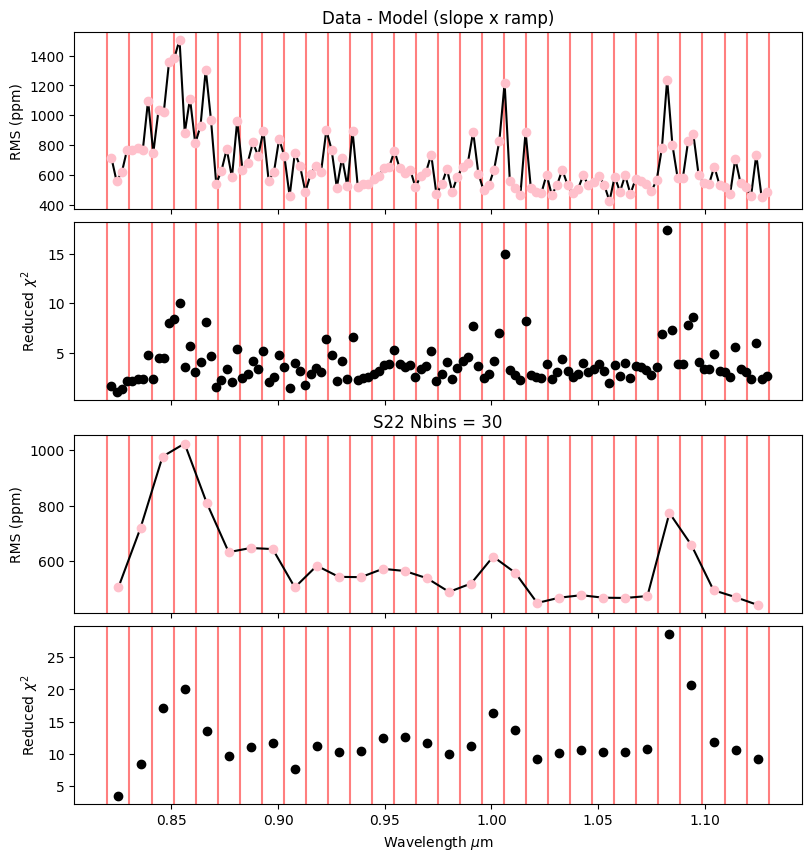

In [16]:
S22_bin_edges = np.linspace(0.82,1.13,31) * u.micron

for edge in S22_bin_edges:
    print(f'{edge.value:.6f}')
    
rms = bin_testing(visit='S22',bin_edges = S22_bin_edges,
        print_results = True,plot=True)

Wavelength Median_rel_err linear_rms r_chisq
0.82183 573 715 1.596
0.82429 554 556 1.036
0.82675 539 617 1.347
0.82921 531 768 2.156
0.83167 524 763 2.186
0.83412 519 781 2.330
0.83658 514 767 2.289
0.83904 509 1098 4.790
0.84150 500 747 2.295
0.84396 497 1035 4.465
0.84642 492 1020 4.440
0.84887 487 1356 7.986
0.85133 485 1382 8.393
0.85379 482 1506 10.057
0.85625 472 883 3.593
0.85871 473 1111 5.688
0.86117 467 810 3.096
0.86362 466 928 4.090
0.86608 465 1306 8.119
0.86854 455 969 4.658
0.87100 441 540 1.542
0.87346 430 628 2.189
0.87592 425 772 3.399
0.87838 420 583 1.985
0.88083 419 962 5.420
0.88329 412 635 2.439
0.88575 407 681 2.882
0.88821 405 817 4.189
0.89067 401 726 3.365
0.89313 400 896 5.169
0.89558 393 559 2.082
0.89804 389 616 2.584
0.90050 389 841 4.815
0.90296 388 723 3.577
0.90542 383 456 1.453
0.90788 382 748 3.945
0.91034 377 656 3.112
0.91279 370 486 1.777
0.91525 364 603 2.821
0.91771 361 662 3.453
0.92017 359 621 3.077
0.92263 359 898 6.429
0.92509 358 769 4.742


🌈🤖 It looks like you're trying to bin in wavelength for a
`Rainbow` object that might not be normalized. In the
current version of `chromatic`, binning before normalizing
might give inaccurate results if the typical uncertainty
varies strongly with wavelength.

Please consider normalizing first, for example with
`rainbow.normalize().bin(...)`
so that all uncertainties will effectively be relative,
and the inverse variance weighting used for binning
wavelengths together will give more reasonable answers.

If you really need to bin before normalizing, please submit
an Issue at github.com/zkbt/chromatic/, and we'll try to
prioritize implementing a statistically sound solution as
soon as possible!



  0%|          | 0/160 [00:00<?, ?it/s]

BINNED: Wavelength Median_rel_err linear_rms r_chisq
0.81937 573 715 1.596
0.82675 312 521 2.870
0.85010 122 872 52.729
0.87469 214 556 6.933
0.88452 205 683 11.378
0.89681 160 653 17.052
0.90788 219 507 5.483
0.91648 182 525 8.573
0.92754 158 583 13.889
0.94107 141 533 14.593
0.95459 149 601 16.636
0.96442 191 529 7.900
0.97057 232 627 7.510
0.97548 230 475 4.393
0.98163 185 508 7.701
1.00007 92 537 35.011
1.01974 155 483 9.899
1.02834 177 447 6.548
1.03449 217 552 6.653
1.04063 176 484 7.773
1.05047 136 463 11.831
1.06153 152 471 9.866
1.07013 174 506 8.657
1.08734 90 631 49.854
1.10701 134 464 12.242
1.11807 151 467 9.865
1.12650 180 492 7.677


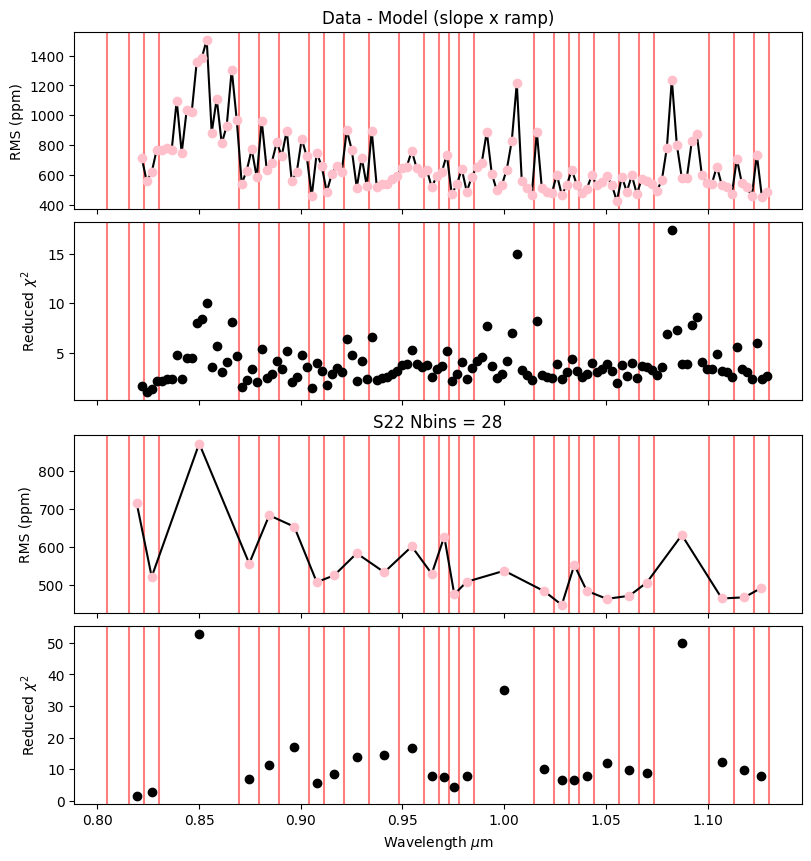

In [17]:
S22_bin_edges = np.array([0.805,
                   0.81568514, 
                   0.82306047, 
                   0.8304358 ,0.8697709 , 
                   0.87960467,
                   0.88943845, 
                   0.90418911,
                   0.91156444, 
                   0.92139821, 
                   0.93369043, 
                   0.94844109, 
                   0.96073331, 0.96810864, 
                   0.97302553, 
                   0.97794241,
                   0.98531775, 
                   1.01481907,
                   1.02465284, 
                   1.03202817, 
                   1.03694506, 
                   1.04432039, 
                   1.05661261, 1.06644638, 
                   1.07382171, 
                          1.10086459,
                   1.11315681,
                   1.12299059, 1.13]) * u.micron

# for edge in S22_bin_edges:
#     print(f'{edge.value:.6f}')
    
rms = bin_testing(visit='S22',bin_edges = S22_bin_edges,
        print_results = True,plot=True)

0.820000
0.834762
0.849524
0.864286
0.879048
0.893810
0.908571
0.923333
0.938095
0.952857
0.967619
0.982381
0.997143
1.011905
1.026667
1.041429
1.056190
1.070952
1.085714
1.100476
1.115238
1.130000
Wavelength Median_rel_err linear_rms r_chisq
0.82183 573 715 1.596
0.82429 554 556 1.036
0.82675 539 617 1.347
0.82921 531 768 2.156
0.83167 524 763 2.186
0.83412 519 781 2.330
0.83658 514 767 2.289
0.83904 509 1098 4.790
0.84150 500 747 2.295
0.84396 497 1035 4.465
0.84642 492 1020 4.440
0.84887 487 1356 7.986
0.85133 485 1382 8.393
0.85379 482 1506 10.057
0.85625 472 883 3.593
0.85871 473 1111 5.688
0.86117 467 810 3.096
0.86362 466 928 4.090
0.86608 465 1306 8.119
0.86854 455 969 4.658
0.87100 441 540 1.542
0.87346 430 628 2.189
0.87592 425 772 3.399
0.87838 420 583 1.985
0.88083 419 962 5.420
0.88329 412 635 2.439
0.88575 407 681 2.882
0.88821 405 817 4.189
0.89067 401 726 3.365
0.89313 400 896 5.169
0.89558 393 559 2.082
0.89804 389 616 2.584
0.90050 389 841 4.815
0.90296 388 723 3.577


🌈🤖 It looks like you're trying to bin in wavelength for a
`Rainbow` object that might not be normalized. In the
current version of `chromatic`, binning before normalizing
might give inaccurate results if the typical uncertainty
varies strongly with wavelength.

Please consider normalizing first, for example with
`rainbow.normalize().bin(...)`
so that all uncertainties will effectively be relative,
and the inverse variance weighting used for binning
wavelengths together will give more reasonable answers.

If you really need to bin before normalizing, please submit
an Issue at github.com/zkbt/chromatic/, and we'll try to
prioritize implementing a statistically sound solution as
soon as possible!



  0%|          | 0/160 [00:00<?, ?it/s]

BINNED: Wavelength Median_rel_err linear_rms r_chisq
0.82738 225 520 5.481
0.84214 204 840 17.428
0.85690 194 982 26.472
0.87167 180 734 17.116
0.88643 166 683 17.315
0.90119 158 559 12.838
0.91595 149 565 14.734
0.93071 144 559 15.469
0.94548 139 520 14.301
0.96024 135 557 17.391
0.97500 132 513 15.383
0.98976 131 495 14.566
1.00452 129 630 24.384
1.01929 127 459 13.461
1.03405 125 453 13.510
1.04881 124 470 14.702
1.06357 124 470 14.826
1.07833 123 627 26.780
1.09310 122 611 25.535
1.10786 123 482 15.812
1.12262 123 440 13.039


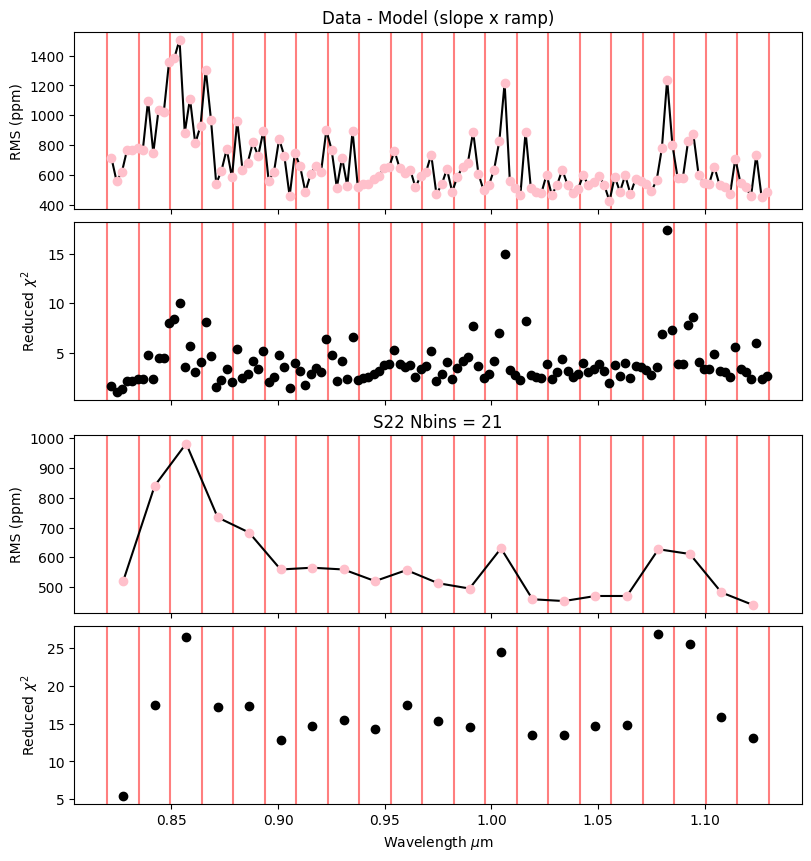

In [18]:
S22_bin_edges = np.linspace(0.82,1.13,22) * u.micron

for edge in S22_bin_edges:
    print(f'{edge.value:.6f}')
    
rms = bin_testing(visit='S22',bin_edges = S22_bin_edges,
        print_results = True,plot=True)